# ECMWF Ensemble Forecast Data

Processes monthly ensemble forecast files (one NetCDF per month) for:
- **t2m** – 2m temperature (K)
- **tprate** – precipitation rate
- **mslp** – mean sea level pressure (Pa)

Data is on a regular lat/lon grid. Eastern Norway subset used: 60.5–62.5°N, 9.5–11.5°E.

## These are the Min Max for Eastern Norway
Min Latitude: 60.5  
Max Latitude: 62.5  
Min Longitude: 9.5  
Max Longitude: 11.5  

In [56]:
lat_min = 60.5
lat_max = 62.5
lon_min = 9.5
lon_max = 11.5

# Preprocess

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import ecmwf
import copy
import os
from pandas.tseries.offsets import MonthEnd
import matplotlib.patches as mpatches

# Load data

In [ ]:
def load_ecmwf_monthly(directory):
    months = ["January", "February", "March", "April", "May", "June",
              "July", "August", "September", "October", "November", "December"]
    files = sorted([f for f in os.listdir(directory) if f.endswith(".nc")],
                   key=lambda x: int(x.split("_")[-1].split(".")[0][2:]))
    ds_list = []
    for f in files:
        month_num = int(f.split("_")[-1].split(".")[0][2:])
        ds = xr.open_dataset(os.path.join(directory, f))
        ds = ds.expand_dims("month").assign_coords(month=[months[month_num - 1]])
        ds_list.append(ds)
        fpath = os.path.join(directory, f)
        print(f"Loaded {months[month_num - 1]}: {fpath}")
    return xr.concat(ds_list, dim="month", join="outer")

# TG (t2m) - Temperature

In [58]:
dataset_t2m = load_ecmwf_monthly("data.nosync/ecmwf_tg.nosync")

Loaded file for January: data.nosync/ecmwf_tg.nosync/ecmwf_ensfcst_t2m_im1.nc
Loaded file for February: data.nosync/ecmwf_tg.nosync/ecmwf_ensfcst_t2m_im2.nc
Loaded file for March: data.nosync/ecmwf_tg.nosync/ecmwf_ensfcst_t2m_im3.nc
Loaded file for April: data.nosync/ecmwf_tg.nosync/ecmwf_ensfcst_t2m_im4.nc
Loaded file for May: data.nosync/ecmwf_tg.nosync/ecmwf_ensfcst_t2m_im5.nc
Loaded file for June: data.nosync/ecmwf_tg.nosync/ecmwf_ensfcst_t2m_im6.nc
Loaded file for July: data.nosync/ecmwf_tg.nosync/ecmwf_ensfcst_t2m_im7.nc
Loaded file for August: data.nosync/ecmwf_tg.nosync/ecmwf_ensfcst_t2m_im8.nc
Loaded file for September: data.nosync/ecmwf_tg.nosync/ecmwf_ensfcst_t2m_im9.nc
Loaded file for October: data.nosync/ecmwf_tg.nosync/ecmwf_ensfcst_t2m_im10.nc
Loaded file for November: data.nosync/ecmwf_tg.nosync/ecmwf_ensfcst_t2m_im11.nc
Loaded file for December: data.nosync/ecmwf_tg.nosync/ecmwf_ensfcst_t2m_im12.nc


/var/folders/kr/14bnw07j4rl47c8fc6dkk36m0000gn/T/ipykernel_3113/2682519800.py:47: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  dataset_xa = xr.concat(datasets_list, dim="month")


In [59]:
dataset_t2m

<xarray.Dataset> Size: 475MB
Dimensions:    (month: 12, year: 31, time: 6, number: 51, latitude: 18,
                longitude: 29)
Coordinates:
  * longitude  (longitude) float32 116B 4.5 5.5 6.5 7.5 ... 29.5 30.5 31.5 32.5
  * latitude   (latitude) float32 72B 71.5 70.5 69.5 68.5 ... 56.5 55.5 54.5
  * number     (number) int32 204B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
  * time       (time) int64 48B 1 2 3 4 5 6
  * year       (year) int64 248B 1993 1994 1995 1996 ... 2020 2021 2022 2023
  * month      (month) <U9 432B 'January' 'February' ... 'November' 'December'
    system     int32 4B 51
Data variables:
    t2m        (month, year, time, number, latitude, longitude) float64 475MB ...
Attributes:
    Conventions:  CF-1.6

In [60]:
dataset_t2m.info()

xarray.Dataset {
dimensions:
	month = 12 ;
	year = 31 ;
	time = 6 ;
	number = 51 ;
	latitude = 18 ;
	longitude = 29 ;

variables:
	float64 t2m(month, year, time, number, latitude, longitude) ;
		t2m:units = K ;
		t2m:long_name = 2 metre temperature ;
	float32 longitude(longitude) ;
		longitude:units = degrees_east ;
		longitude:long_name = longitude ;
	float32 latitude(latitude) ;
		latitude:units = degrees_north ;
		latitude:long_name = latitude ;
	int32 number(number) ;
		number:long_name = ensemble_member ;
	int64 time(time) ;
	int64 year(year) ;
	<U9 month(month) ;
	int32 system() ;
		system:long_name = system ;

// global attributes:
	:Conventions = CF-1.6 ;
}

In [61]:
print(dataset_t2m.t2m.attrs['units'], dataset_t2m.t2m.attrs['long_name'])

K
2 metre temperature


# RR (tprate) (Precipitation)

In [62]:
dataset_tprate = load_ecmwf_monthly("data.nosync/ecmwf_rr.nosync")

Loaded file for January: data.nosync/ecmwf_rr.nosync/ecmwf_ensfcst_im1.nc
Loaded file for February: data.nosync/ecmwf_rr.nosync/ecmwf_ensfcst_im2.nc
Loaded file for March: data.nosync/ecmwf_rr.nosync/ecmwf_ensfcst_im3.nc
Loaded file for April: data.nosync/ecmwf_rr.nosync/ecmwf_ensfcst_im4.nc
Loaded file for May: data.nosync/ecmwf_rr.nosync/ecmwf_ensfcst_im5.nc
Loaded file for June: data.nosync/ecmwf_rr.nosync/ecmwf_ensfcst_im6.nc
Loaded file for July: data.nosync/ecmwf_rr.nosync/ecmwf_ensfcst_im7.nc
Loaded file for August: data.nosync/ecmwf_rr.nosync/ecmwf_ensfcst_im8.nc
Loaded file for September: data.nosync/ecmwf_rr.nosync/ecmwf_ensfcst_im9.nc
Loaded file for October: data.nosync/ecmwf_rr.nosync/ecmwf_ensfcst_im10.nc
Loaded file for November: data.nosync/ecmwf_rr.nosync/ecmwf_ensfcst_im11.nc
Loaded file for December: data.nosync/ecmwf_rr.nosync/ecmwf_ensfcst_im12.nc


/var/folders/kr/14bnw07j4rl47c8fc6dkk36m0000gn/T/ipykernel_3113/3169349757.py:49: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  dataset_xa = xr.concat(datasets_list, dim="month")


In [64]:
# find unit from dataset
print(dataset_tprate.tprate.attrs['units'])

# find other information from dataset
print(dataset_tprate.tprate.attrs['long_name'])

m s**-1
Mean total precipitation rate


In [65]:
dataset_tprate.info()

xarray.Dataset {
dimensions:
	month = 12 ;
	year = 31 ;
	time = 6 ;
	number = 51 ;
	latitude = 18 ;
	longitude = 29 ;

variables:
	float64 tprate(month, year, time, number, latitude, longitude) ;
		tprate:units = m s**-1 ;
		tprate:long_name = Mean total precipitation rate ;
	float32 longitude(longitude) ;
		longitude:units = degrees_east ;
		longitude:long_name = longitude ;
	float32 latitude(latitude) ;
		latitude:units = degrees_north ;
		latitude:long_name = latitude ;
	int32 number(number) ;
		number:long_name = ensemble_member ;
	int64 time(time) ;
	int64 year(year) ;
	<U9 month(month) ;
	int32 system() ;
		system:long_name = system ;

// global attributes:
	:Conventions = CF-1.6 ;
}

# MSLP (PP) – Mean sea level pressure

In [66]:
dataset_msl = load_ecmwf_monthly("data.nosync/ecmwf_mslp.nosync")

Loaded file for January: data.nosync/ecmwf_mslp.nosync/ecmwf_ensfcst_mslp_im1.nc
Loaded file for February: data.nosync/ecmwf_mslp.nosync/ecmwf_ensfcst_mslp_im2.nc
Loaded file for March: data.nosync/ecmwf_mslp.nosync/ecmwf_ensfcst_mslp_im3.nc
Loaded file for April: data.nosync/ecmwf_mslp.nosync/ecmwf_ensfcst_mslp_im4.nc
Loaded file for May: data.nosync/ecmwf_mslp.nosync/ecmwf_ensfcst_mslp_im5.nc
Loaded file for June: data.nosync/ecmwf_mslp.nosync/ecmwf_ensfcst_mslp_im6.nc
Loaded file for July: data.nosync/ecmwf_mslp.nosync/ecmwf_ensfcst_mslp_im7.nc
Loaded file for August: data.nosync/ecmwf_mslp.nosync/ecmwf_ensfcst_mslp_im8.nc
Loaded file for September: data.nosync/ecmwf_mslp.nosync/ecmwf_ensfcst_mslp_im9.nc
Loaded file for October: data.nosync/ecmwf_mslp.nosync/ecmwf_ensfcst_mslp_im10.nc
Loaded file for November: data.nosync/ecmwf_mslp.nosync/ecmwf_ensfcst_mslp_im11.nc
Loaded file for December: data.nosync/ecmwf_mslp.nosync/ecmwf_ensfcst_mslp_im12.nc


/var/folders/kr/14bnw07j4rl47c8fc6dkk36m0000gn/T/ipykernel_3113/690663462.py:49: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  dataset_xa = xr.concat(datasets_list, dim="month")


In [67]:
dataset_msl

<xarray.Dataset> Size: 475MB
Dimensions:    (month: 12, year: 31, time: 6, number: 51, latitude: 18,
                longitude: 29)
Coordinates:
  * longitude  (longitude) float32 116B 4.5 5.5 6.5 7.5 ... 29.5 30.5 31.5 32.5
  * latitude   (latitude) float32 72B 71.5 70.5 69.5 68.5 ... 56.5 55.5 54.5
  * number     (number) int32 204B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
  * time       (time) int64 48B 1 2 3 4 5 6
  * year       (year) int64 248B 1993 1994 1995 1996 ... 2020 2021 2022 2023
  * month      (month) <U9 432B 'January' 'February' ... 'November' 'December'
    system     int32 4B 51
Data variables:
    msl        (month, year, time, number, latitude, longitude) float64 475MB ...
Attributes:
    Conventions:  CF-1.6

In [68]:
print(dataset_msl.msl.attrs['units'], dataset_msl.msl.attrs['long_name'])

Pa
Mean sea level pressure


In [69]:
dataset_msl.info()

xarray.Dataset {
dimensions:
	month = 12 ;
	year = 31 ;
	time = 6 ;
	number = 51 ;
	latitude = 18 ;
	longitude = 29 ;

variables:
	float64 msl(month, year, time, number, latitude, longitude) ;
		msl:units = Pa ;
		msl:long_name = Mean sea level pressure ;
		msl:standard_name = air_pressure_at_mean_sea_level ;
	float32 longitude(longitude) ;
		longitude:units = degrees_east ;
		longitude:long_name = longitude ;
	float32 latitude(latitude) ;
		latitude:units = degrees_north ;
		latitude:long_name = latitude ;
	int32 number(number) ;
		number:long_name = ensemble_member ;
	int64 time(time) ;
	int64 year(year) ;
	<U9 month(month) ;
	int32 system() ;
		system:long_name = system ;

// global attributes:
	:Conventions = CF-1.6 ;
}

# ------------- COMMON EDITS -------------

# Change naming

In [70]:
# ecwmf_t2m_eastnor_avgmonthly = ecwmf_t2m_eastnor.resample(time='1M').mean()
# ecwmf_tprate_eastnor_avgmonthly = ecwmf_tprate_eastnor.resample(time='1M').sum()
# dataset_eastnor_avgmonthly = ecwmf_mslp_eastnor.resample(time='1M').mean()

In [71]:
dataset_t2m = ecmwf.rename_netcdf_dimension(dataset_t2m, {"number": "ensemble_member", 
                                                  "time": "forecast_index"})

dataset_tprate = ecmwf.rename_netcdf_dimension(dataset_tprate, {"number": "ensemble_member", 
                                                  "time": "forecast_index"})

dataset_msl = ecmwf.rename_netcdf_dimension(dataset_msl, {"number": "ensemble_member", 
                                                  "time": "forecast_index"})
dataset_t2m

<xarray.Dataset> Size: 475MB
Dimensions:          (month: 12, year: 31, forecast_index: 6,
                      ensemble_member: 51, latitude: 18, longitude: 29)
Coordinates:
  * longitude        (longitude) float32 116B 4.5 5.5 6.5 7.5 ... 30.5 31.5 32.5
  * latitude         (latitude) float32 72B 71.5 70.5 69.5 ... 56.5 55.5 54.5
  * ensemble_member  (ensemble_member) int32 204B 0 1 2 3 4 5 ... 46 47 48 49 50
  * forecast_index   (forecast_index) int64 48B 1 2 3 4 5 6
  * year             (year) int64 248B 1993 1994 1995 1996 ... 2021 2022 2023
  * month            (month) <U9 432B 'January' 'February' ... 'December'
    system           int32 4B 51
Data variables:
    t2m              (month, year, forecast_index, ensemble_member, latitude, longitude) float64 475MB ...
Attributes:
    Conventions:  CF-1.6

# Inspect Ensembles

In [72]:
data_slice_t2m = dataset_t2m['t2m'].isel(
    year=0,
    month=0,
    latitude=0,
    longitude=0,
    forecast_index=slice(0, 5)  # First 5 forecast months
)
df_slice_t2m = data_slice_t2m.to_pandas().T
df_slice_t2m

forecast_index,1,2,3,4,5
ensemble_member,,,,,
0,275.800787,275.131014,273.538261,273.358566,275.047701
1,274.608264,272.613647,273.476184,272.295097,275.681535
2,275.706039,274.051209,275.469168,272.665922,273.490887
3,274.230904,273.267085,271.863828,271.465232,273.709788
4,274.783059,274.506982,272.123570,271.731507,274.727517
5,276.042559,273.616673,271.499537,274.363225,276.668225
6,273.254016,271.889966,272.077829,272.365341,274.722616
7,273.979331,271.788683,271.189154,271.615522,274.021805
8,275.621092,270.004800,271.862195,273.093924,274.482478


In [73]:
data_slice_tprate = dataset_tprate['tprate'].isel(
    year=0,
    month=0,
    latitude=0,
    longitude=0,
    forecast_index=slice(0, 5)  # First 5 forecast months
)
df_slice_tprate = data_slice_tprate.to_pandas().T
df_slice_tprate

forecast_index,1,2,3,4,5
ensemble_member,,,,,
0,2.843812e-08,3.148215e-08,3.655554e-08,2.011234e-08,6.559159e-09
1,3.176300e-08,3.556804e-08,3.689980e-08,1.875340e-08,6.649756e-09
2,3.741620e-08,4.207284e-08,2.256749e-08,2.274869e-08,1.242073e-08
3,4.658453e-08,2.861932e-08,4.125748e-08,2.600109e-08,1.380685e-08
4,3.593948e-08,2.165247e-08,3.385577e-08,1.565501e-08,9.113970e-09
5,3.868455e-08,2.679833e-08,4.098569e-08,2.417105e-08,1.524733e-08
6,4.335025e-08,4.058706e-08,2.498641e-08,2.150752e-08,1.396992e-08
7,5.098750e-08,3.709005e-08,2.343722e-08,1.375249e-08,8.978076e-09
8,4.402972e-08,4.054177e-08,2.276681e-08,1.210364e-08,1.558253e-08


In [74]:
data_slice_msl = dataset_msl['msl'].isel(
    year=0,
    month=0,
    latitude=0,
    longitude=0,
    forecast_index=slice(0, 5)  # First 5 forecast months
)
df_slice_msl = data_slice_msl.to_pandas().T
df_slice_msl

forecast_index,1,2,3,4,5
ensemble_member,,,,,
0,100384.182627,99500.133564,98776.429080,100639.657012,102218.213487
1,101253.034854,99521.433068,99782.172498,101324.232633,101752.017608
2,100753.453798,99567.980860,101050.330588,101296.112502,101638.220822
3,98094.127001,101129.306276,100436.115125,101268.829991,102437.670171
4,99199.188330,101446.285969,100315.856691,101984.158267,101716.239229
5,99714.564523,99495.347159,101205.410121,101469.260714,101349.480921
6,98414.816158,99439.944517,100689.196307,101397.344974,101951.969691
7,99052.245686,100475.842289,101446.405629,101177.648970,101926.841063
8,100238.316925,99416.491131,101714.922967,102145.579786,101827.283832


# Select 0-24 Ensemble Members

In [75]:
dataset_t2m = ecmwf.select_ensemble_members(dataset_t2m)
dataset_tprate = ecmwf.select_ensemble_members(dataset_tprate)
dataset_msl = ecmwf.select_ensemble_members(dataset_msl)

dataset_msl

<xarray.Dataset> Size: 233MB
Dimensions:          (month: 12, year: 31, forecast_index: 6,
                      ensemble_member: 25, latitude: 18, longitude: 29)
Coordinates:
  * longitude        (longitude) float32 116B 4.5 5.5 6.5 7.5 ... 30.5 31.5 32.5
  * latitude         (latitude) float32 72B 71.5 70.5 69.5 ... 56.5 55.5 54.5
  * ensemble_member  (ensemble_member) int32 100B 0 1 2 3 4 5 ... 20 21 22 23 24
  * forecast_index   (forecast_index) int64 48B 1 2 3 4 5 6
  * year             (year) int64 248B 1993 1994 1995 1996 ... 2021 2022 2023
  * month            (month) <U9 432B 'January' 'February' ... 'December'
    system           int32 4B 51
Data variables:
    msl              (month, year, forecast_index, ensemble_member, latitude, longitude) float64 233MB ...
Attributes:
    Conventions:  CF-1.6

# How many NAN are left after removing Ensmebler 0-24? -> October 2022
Seems that October 2022 is a motnh where all data is gone. Why?

In [76]:
has_nan = np.isnan(dataset_t2m.t2m.values).any()
num_nan = np.isnan(dataset_t2m.t2m.values).sum()
print(f"Number of empty (NaN) cells in t2m: {num_nan}")

Number of empty (NaN) cells in t2m: 78300


In [77]:
has_nan = np.isnan(dataset_tprate.tprate.values).any()
num_nan = np.isnan(dataset_tprate.tprate.values).sum()
print(f"Number of empty (NaN) cells in tprate: {num_nan}")

Number of empty (NaN) cells in tprate: 78300


In [78]:
has_nan = np.isnan(dataset_msl.msl.values).any()
num_nan = np.isnan(dataset_msl.msl.values).sum()
print(f"Number of empty (NaN) cells in msl: {num_nan}")

Number of empty (NaN) cells in msl: 156600


In [79]:
def where_nan_summary(da, var_name="Var"):
    print(f"\n------ {var_name} ------")
    nan_mask = np.isnan(da.values)
    total_nan = nan_mask.sum()
    print(f"Total nan: {total_nan}")
    axes = da.dims
    coords = list(da.coords)
    shape = da.shape

    # For each dimension, print which indices contain any NaN
    for axis, dim in enumerate(axes):
        nan_ax = nan_mask.any(axis=tuple(i for i in range(len(shape)) if i != axis))
        where = np.where(nan_ax)[0]
        if len(where) == 0:
            print(f"No NaN found along dimension '{dim}'")
        else:
            print(f"NaN present at these '{dim}' indices: {where}")
            try:
                val_at = da[dim].values[where]
                print(f"Corresponding {dim} values: {val_at}")
            except Exception:
                pass

# Check patterns for t2m, tprate, msl
where_nan_summary(dataset_t2m["t2m"], "t2m")
where_nan_summary(dataset_tprate["tprate"], "tprate")
where_nan_summary(dataset_msl["msl"], "msl")

# For further info, print indices of all nans for a selected variable (e.g., t2m)
nan_idx = np.argwhere(np.isnan(dataset_t2m['t2m'].values))
if nan_idx.size > 0:
    dims = dataset_t2m['t2m'].dims
    print("\nFirst 10 NaN t2m locations (dimension indices):")
    for row in nan_idx[:10]:
        desc = ", ".join(f"{dim}={val}" for dim, val in zip(dims, row))
        print(desc)



------ t2m ------
Total nan: 78300
NaN present at these 'month' indices: [9]
Corresponding month values: ['October']
NaN present at these 'year' indices: [29]
Corresponding year values: [2022]
NaN present at these 'forecast_index' indices: [0 1 2 3 4 5]
Corresponding forecast_index values: [1 2 3 4 5 6]
NaN present at these 'ensemble_member' indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]
Corresponding ensemble_member values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]
NaN present at these 'latitude' indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
Corresponding latitude values: [71.5 70.5 69.5 68.5 67.5 66.5 65.5 64.5 63.5 62.5 61.5 60.5 59.5 58.5
 57.5 56.5 55.5 54.5]
NaN present at these 'longitude' indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28]
Corresponding longitude values: [ 4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5 14.5 15.5 16.5 1

In [80]:
# Combined check for t2m, tprate, msl for October 2022 NaN status in one loop

def get_month_year_index(da, year, month_str):
    # month_str: e.g., "October"
    year_idx = np.where(da.coords['year'].values == year)[0]
    month_idx = np.where(da.coords['month'].values == month_str)[0]
    if year_idx.size == 0 or month_idx.size == 0:
        raise ValueError(f"Year {year} or month {month_str} not found.")
    return int(month_idx[0]), int(year_idx[0])

variables = [
    (dataset_t2m["t2m"], "t2m"),
    (dataset_tprate["tprate"], "tprate"),
    (dataset_msl["msl"], "msl"),
]

for var, name in variables:
    try:
        month_idx, year_idx = get_month_year_index(var, 2022, "October")
        oct_slice = var.isel(month=month_idx, year=year_idx)
        full_nan_mask = np.isnan(var.values)
        oct_nan_mask = np.isnan(oct_slice.values)

        print(f"\n--- {name} ---")
        print(f"Shape of all-data: {var.shape}")
        print(f"Shape of October 2022 slice: {oct_slice.shape}")
        print(f"Total in dataset: {var.size}, total NaN: {full_nan_mask.sum()}")
        print(f"October 2022: shape {oct_slice.shape}, total: {oct_nan_mask.size}, total NaN: {oct_nan_mask.sum()}")

        if oct_nan_mask.all():
            print(f"All values in October 2022 are NaN for {name}.")
            if full_nan_mask.sum() == oct_nan_mask.size:
                print(f"All NaN values in the entire {name} dataset are confined to October 2022.")
            else:
                print(f"There are NaNs outside October 2022 in {name}.")
        else:
            print(f"Not all values in October 2022 are NaN for {name}.")
    except Exception as e:
        print(f"Could not check {name}: {e}")


--- t2m ---
Shape of all-data: (12, 31, 6, 25, 18, 29)
Shape of October 2022 slice: (6, 25, 18, 29)
Total in dataset: 29127600, total NaN: 78300
October 2022: shape (6, 25, 18, 29), total: 78300, total NaN: 78300
All values in October 2022 are NaN for t2m.
All NaN values in the entire t2m dataset are confined to October 2022.

--- tprate ---
Shape of all-data: (12, 31, 6, 25, 18, 29)
Shape of October 2022 slice: (6, 25, 18, 29)
Total in dataset: 29127600, total NaN: 78300
October 2022: shape (6, 25, 18, 29), total: 78300, total NaN: 78300
All values in October 2022 are NaN for tprate.
All NaN values in the entire tprate dataset are confined to October 2022.

--- msl ---
Shape of all-data: (12, 31, 6, 25, 18, 29)
Shape of October 2022 slice: (6, 25, 18, 29)
Total in dataset: 29127600, total NaN: 156600
October 2022: shape (6, 25, 18, 29), total: 78300, total NaN: 78300
All values in October 2022 are NaN for msl.
There are NaNs outside October 2022 in msl.


# Unit Information (out of interest only, no impact)

In [ ]:
print("\nVariable Attributes:")

for var_name, var in dataset_t2m.data_vars.items():
    print(f"\nVariable: {var_name}")
    print(var.attrs)

for var_name, var in dataset_tprate.data_vars.items():
    print(f"\nVariable: {var_name}")
    print(var.attrs)

for var_name, var in dataset_msl.data_vars.items():
    print(f"\nVariable: {var_name}")
    print(var.attrs)


Variable Attributes:

Variable: t2m
{'units': 'K', 'long_name': '2 metre temperature'}

Variable: tprate
{'units': 'm s**-1', 'long_name': 'Mean total precipitation rate'}

Variable: msl
{'units': 'Pa', 'long_name': 'Mean sea level pressure', 'standard_name': 'air_pressure_at_mean_sea_level'}


# Unit conversions

# Precipitation Processing

In [82]:
for var_name, var in dataset_tprate.data_vars.items():
    print(f"\nVariable: {var_name}")
    print(var.attrs)


Variable: tprate
{'units': 'm s**-1', 'long_name': 'Mean total precipitation rate'}


### --- Per Second to Per Month

In [83]:
dataset_tprate = ecmwf.modify_per_second_to_per_month(dataset_tprate, variable="tprate")
dataset_tprate

<xarray.Dataset> Size: 233MB
Dimensions:          (month: 12, year: 31, forecast_index: 6,
                      ensemble_member: 25, latitude: 18, longitude: 29)
Coordinates:
  * longitude        (longitude) float32 116B 4.5 5.5 6.5 7.5 ... 30.5 31.5 32.5
  * latitude         (latitude) float32 72B 71.5 70.5 69.5 ... 56.5 55.5 54.5
  * ensemble_member  (ensemble_member) int32 100B 0 1 2 3 4 5 ... 20 21 22 23 24
  * forecast_index   (forecast_index) int64 48B 1 2 3 4 5 6
  * year             (year) int64 248B 1993 1994 1995 1996 ... 2021 2022 2023
  * month            (month) <U9 432B 'January' 'February' ... 'December'
    system           int32 4B 51
Data variables:
    tprate           (month, year, forecast_index, ensemble_member, latitude, longitude) float64 233MB ...
Attributes:
    Conventions:  CF-1.6

### --- convert 'm' to 'mm'

In [84]:
# convert tprate to mm/month rather than m/month

dataset_tprate["tprate"] = dataset_tprate["tprate"] * 1000
dataset_tprate

<xarray.Dataset> Size: 233MB
Dimensions:          (month: 12, year: 31, forecast_index: 6,
                      ensemble_member: 25, latitude: 18, longitude: 29)
Coordinates:
  * longitude        (longitude) float32 116B 4.5 5.5 6.5 7.5 ... 30.5 31.5 32.5
  * latitude         (latitude) float32 72B 71.5 70.5 69.5 ... 56.5 55.5 54.5
  * ensemble_member  (ensemble_member) int32 100B 0 1 2 3 4 5 ... 20 21 22 23 24
  * forecast_index   (forecast_index) int64 48B 1 2 3 4 5 6
  * year             (year) int64 248B 1993 1994 1995 1996 ... 2021 2022 2023
  * month            (month) <U9 432B 'January' 'February' ... 'December'
    system           int32 4B 51
Data variables:
    tprate           (month, year, forecast_index, ensemble_member, latitude, longitude) float64 233MB ...
Attributes:
    Conventions:  CF-1.6

# Temperature Processing

In [85]:
for var_name, var in dataset_t2m.data_vars.items():
    print(f"\nVariable: {var_name}")
    print(var.attrs)


Variable: t2m
{'units': 'K', 'long_name': '2 metre temperature'}


### --- Kelvin to Celcius

In [86]:
# Convert t2m to Celsius
dataset_t2m["t2m"] = dataset_t2m["t2m"] - 273.15
dataset_t2m

<xarray.Dataset> Size: 233MB
Dimensions:          (month: 12, year: 31, forecast_index: 6,
                      ensemble_member: 25, latitude: 18, longitude: 29)
Coordinates:
  * longitude        (longitude) float32 116B 4.5 5.5 6.5 7.5 ... 30.5 31.5 32.5
  * latitude         (latitude) float32 72B 71.5 70.5 69.5 ... 56.5 55.5 54.5
  * ensemble_member  (ensemble_member) int32 100B 0 1 2 3 4 5 ... 20 21 22 23 24
  * forecast_index   (forecast_index) int64 48B 1 2 3 4 5 6
  * year             (year) int64 248B 1993 1994 1995 1996 ... 2021 2022 2023
  * month            (month) <U9 432B 'January' 'February' ... 'December'
    system           int32 4B 51
Data variables:
    t2m              (month, year, forecast_index, ensemble_member, latitude, longitude) float64 233MB ...
Attributes:
    Conventions:  CF-1.6

# Pressure Processing

In [87]:
for var_name, var in dataset_msl.data_vars.items():
    print(f"\nVariable: {var_name}")
    print(var.attrs)


Variable: msl
{'units': 'Pa', 'long_name': 'Mean sea level pressure', 'standard_name': 'air_pressure_at_mean_sea_level'}


### --- Pa to hPa

In [88]:
# Convert msl, which is in Pa, to hPa
dataset_msl["msl"] = dataset_msl["msl"] / 100
dataset_msl

<xarray.Dataset> Size: 233MB
Dimensions:          (month: 12, year: 31, forecast_index: 6,
                      ensemble_member: 25, latitude: 18, longitude: 29)
Coordinates:
  * longitude        (longitude) float32 116B 4.5 5.5 6.5 7.5 ... 30.5 31.5 32.5
  * latitude         (latitude) float32 72B 71.5 70.5 69.5 ... 56.5 55.5 54.5
  * ensemble_member  (ensemble_member) int32 100B 0 1 2 3 4 5 ... 20 21 22 23 24
  * forecast_index   (forecast_index) int64 48B 1 2 3 4 5 6
  * year             (year) int64 248B 1993 1994 1995 1996 ... 2021 2022 2023
  * month            (month) <U9 432B 'January' 'February' ... 'December'
    system           int32 4B 51
Data variables:
    msl              (month, year, forecast_index, ensemble_member, latitude, longitude) float64 233MB ...
Attributes:
    Conventions:  CF-1.6

# ------------- MAPPING -------------

# Map All ECMWF Points

In [89]:
print(f"Latitude: min = {dataset_t2m['latitude'].values.min()}, max = {dataset_t2m['latitude'].values.max()}")
print(f"Longitude: min = {dataset_t2m['longitude'].values.min()}, max = {dataset_t2m['longitude'].values.max()}")

Latitude: min = 54.5, max = 71.5
Longitude: min = 4.5, max = 32.5


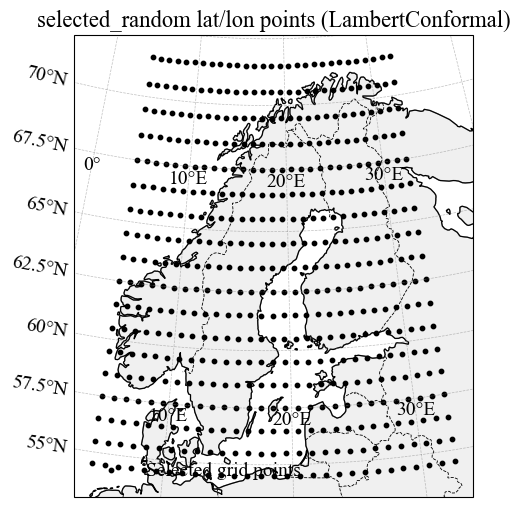

In [90]:
# Extract coordinates from selected_random
latitudes = dataset_t2m["latitude"].values
longitudes = dataset_t2m["longitude"].values
lon_grid, lat_grid = np.meshgrid(longitudes, latitudes)

# Projection centered on region of interest
proj = ccrs.LambertConformal(central_longitude=18.0, central_latitude=64.5)
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': proj})

# Geographic extent
# zoomed_extent = [4, 19, 57, 66]
# ax.set_extent(zoomed_extent, crs=ccrs.PlateCarree())

# # Clean grayscale aesthetic
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0', edgecolor='gray')
# ax.add_feature(cfeature.OCEAN, facecolor='white', edgecolor='gray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle='--', linewidth=0.6)

# # Gridlines and labels
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# # Plot selected grid points
ax.scatter(lon_grid.flatten(), lat_grid.flatten(), color='black', s=10, transform=ccrs.PlateCarree(), label='Selected grid points')

plt.title('selected_random lat/lon points (LambertConformal)')
plt.legend(loc='lower left', frameon=False)
plt.show()


# Select Only Eastern Norway Lcoations
This is actually the max/min:
- Min Latitude: 60.5
- Max Latitude: 62.5
- Min Longitude: 9.5
- Max Longitude: 11.5

So I will use these to align the areas of E-OBS and ECMWF together

In [91]:
datasets = [dataset_t2m, dataset_tprate, dataset_msl]
subset_datasets = []

# Loop through each dataset in the list
for dataset in datasets:
    # Select the subset based on the latitude and longitude bounds
    subset = dataset.sel(
        latitude=slice(lat_max, lat_min),
        longitude=slice(lon_min, lon_max)
    )
    subset_datasets.append(subset)

ecwmf_t2m_eastnor = subset_datasets[0]
ecwmf_tprate_eastnor = subset_datasets[1]
ecwmf_msl_eastnor = subset_datasets[2]

In [92]:
ecwmf_msl_eastnor

<xarray.Dataset> Size: 4MB
Dimensions:          (month: 12, year: 31, forecast_index: 6,
                      ensemble_member: 25, latitude: 3, longitude: 3)
Coordinates:
  * longitude        (longitude) float32 12B 9.5 10.5 11.5
  * latitude         (latitude) float32 12B 62.5 61.5 60.5
  * ensemble_member  (ensemble_member) int32 100B 0 1 2 3 4 5 ... 20 21 22 23 24
  * forecast_index   (forecast_index) int64 48B 1 2 3 4 5 6
  * year             (year) int64 248B 1993 1994 1995 1996 ... 2021 2022 2023
  * month            (month) <U9 432B 'January' 'February' ... 'December'
    system           int32 4B 51
Data variables:
    msl              (month, year, forecast_index, ensemble_member, latitude, longitude) float64 4MB ...
Attributes:
    Conventions:  CF-1.6

# Report: Plot

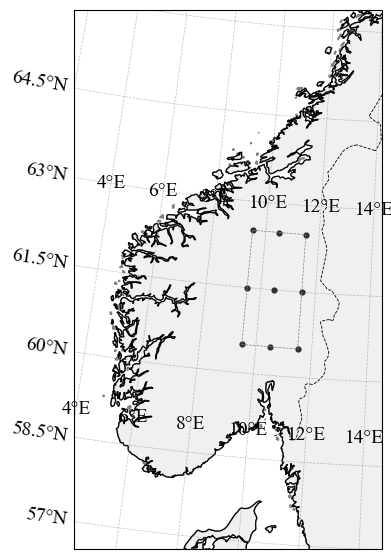

In [ ]:
proj = ccrs.LambertConformal(central_longitude=18.0, central_latitude=64.5)

target_width = 7  # Change this number to resize everything at once!
scale_factor = target_width / 6.0 

# Calculate proportional sizes
base_fs = 10  # Base font size
figsize = (target_width, target_width)
fontsize_title = 14 * scale_factor
fontsize_label = 12 * scale_factor
fontsize_tick  = 12 * scale_factor

plt.rcParams.update({
    'font.family': 'serif',           # Use serif fonts (like Times/CM)
    'font.serif': ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif'], # Priority list
    'mathtext.fontset': 'cm',         # Use Computer Modern for math (if any)
    'font.size': fontsize_label,
    'axes.labelsize': fontsize_label,
    'axes.titlesize': fontsize_title,
    'xtick.labelsize': fontsize_tick,
    'ytick.labelsize': fontsize_tick,
    'legend.fontsize': fontsize_tick,
})


####################

fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': proj})

# --- 3. Set the geographic extent ---
zoomed_extent = [4.5, 14, 57, 66]
ax.set_extent(zoomed_extent, crs=ccrs.PlateCarree())


# --- 7. Add Bounding Box ---
# Create a rectangle patch using the min/max coordinates
# lat_min, lat_max, lon_min, lon_max should be defined in your notebook (Cell 4)
width = lon_max - lon_min
height = lat_max - lat_min

rect = mpatches.Rectangle(
    (lon_min, lat_min), width, height,
    fill=False,             # Transparent background
    edgecolor='gray',       # Gray lines
    linestyle='--',         # Dashed style
    linewidth=0.5,          # Thickness
    transform=ccrs.PlateCarree(), # Important: coordinate system
    zorder=10               # Draw on top
)
ax.add_patch(rect)
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0', edgecolor='gray')
ax.add_feature(cfeature.OCEAN, facecolor='white', edgecolor='gray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle='--', linewidth=0.6)

# --- 5. Add gridlines and labels ---
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False  # <--- Hides x-axis labels (longitude)

gl.ylabel_style = {'size': fontsize_tick, 'family': 'serif'}
gl.xlabel_style = {'size': fontsize_tick, 'family': 'serif'}

# --- 6. Plot the location dots only (no colormap) ---
# Use ecmwf_t2m_eastnor to plot all grid point locations for this region
lon_grid, lat_grid = np.meshgrid(
    ecwmf_t2m_eastnor.longitude.values,
    ecwmf_t2m_eastnor.latitude.values
)

# Plot location points as slightly darker gray dots and make them smaller
slightly_more_dark_gray = '#222222'

# Flatten grids for scatter plotting
ax.scatter(
    lon_grid.flatten(), lat_grid.flatten(),
    color=slightly_more_dark_gray,
    edgecolor=slightly_more_dark_gray,
    s=12, marker='o',   # smaller size (was 16)
    transform=ccrs.PlateCarree(), zorder=5, alpha=0.9
)

plt.show()

# Eastern Map (including the E-OBS point with 0 data)

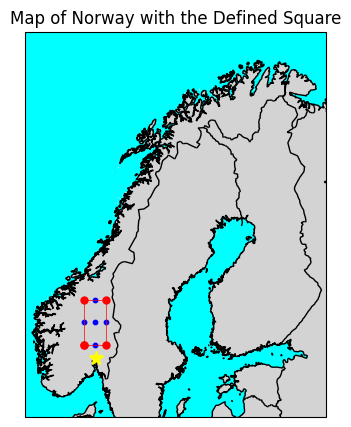

In [39]:
fig, ax = plt.subplots(figsize=(6, 5), subplot_kw={'projection': ccrs.Mercator()})
ax.set_extent([4.0, 32.0, 57.0, 72.0], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='aqua')

# Plot the square
ax.plot([lon_min, lon_min, lon_max, lon_max, lon_min], 
    [lat_min, lat_max, lat_max, lat_min, lat_min], 
    marker='o', color='red', markersize=5, linewidth=0.5, transform=ccrs.PlateCarree())


# plot all lat lon pairs in small blue dots
lon_grid, lat_grid = np.meshgrid(ecwmf_t2m_eastnor.longitude.values, ecwmf_t2m_eastnor.latitude.values)
ax.scatter(lon_grid.flatten(), lat_grid.flatten(), 
    color='blue', s=10, transform=ccrs.PlateCarree())

# add a yellow start in lat lon 59.875, 10.625 where there's no data
ax.plot(10.625, 59.875, marker='*', color='yellow', markersize=10, transform=ccrs.PlateCarree())

plt.title("Map of Norway with the Defined Square")
plt.show()

In [94]:
# Find the min and max for latitude and longitude
lat_min_val = ecwmf_t2m_eastnor.latitude.min().item()
lat_max_val = ecwmf_t2m_eastnor.latitude.max().item()
lon_min_val = ecwmf_t2m_eastnor.longitude.min().item()
lon_max_val = ecwmf_t2m_eastnor.longitude.max().item()

print(f"Min Latitude: {lat_min_val}")
print(f"Max Latitude: {lat_max_val}")
print(f"Min Longitude: {lon_min_val}")
print(f"Max Longitude: {lon_max_val}")

Min Latitude: 60.5
Max Latitude: 62.5
Min Longitude: 9.5
Max Longitude: 11.5


# Average Over Lat Lon

In [95]:
ecwmf_t2m_eastnor_avgloc = ecwmf_t2m_eastnor.mean(dim=['latitude', 'longitude'])
ecwmf_tprate_eastnor_avgloc = ecwmf_tprate_eastnor.mean(dim=['latitude', 'longitude'])
ecwmf_msl_eastnor_avgloc = ecwmf_msl_eastnor.mean(dim=['latitude', 'longitude'])

ecwmf_msl_eastnor_avgloc

<xarray.Dataset> Size: 447kB
Dimensions:          (month: 12, year: 31, forecast_index: 6,
                      ensemble_member: 25)
Coordinates:
  * ensemble_member  (ensemble_member) int32 100B 0 1 2 3 4 5 ... 20 21 22 23 24
  * forecast_index   (forecast_index) int64 48B 1 2 3 4 5 6
  * year             (year) int64 248B 1993 1994 1995 1996 ... 2021 2022 2023
  * month            (month) <U9 432B 'January' 'February' ... 'December'
    system           int32 4B 51
Data variables:
    msl              (month, year, forecast_index, ensemble_member) float64 446kB ...

# Nan still only October 2022?

In [ ]:
def get_month_year_index(da, year, month_str):
    # month_str: e.g., "October"
    year_idx = np.where(da.coords['year'].values == year)[0]
    month_idx = np.where(da.coords['month'].values == month_str)[0]
    if year_idx.size == 0 or month_idx.size == 0:
        raise ValueError(f"Year {year} or month {month_str} not found.")
    return int(month_idx[0]), int(year_idx[0])

variables = [
    (ecwmf_t2m_eastnor_avgloc["t2m"], "t2m"),
    (ecwmf_tprate_eastnor_avgloc["tprate"], "tprate"),
    (ecwmf_msl_eastnor_avgloc["msl"], "msl"),
]

for var, name in variables:
    try:
        month_idx, year_idx = get_month_year_index(var, 2022, "October")
        oct_slice = var.isel(month=month_idx, year=year_idx)
        full_nan_mask = np.isnan(var.values)
        oct_nan_mask = np.isnan(oct_slice.values)

        print(f"\n--- {name} ---")
        print(f"Shape of all-data: {var.shape}")
        print(f"Shape of October 2022 slice: {oct_slice.shape}")
        print(f"Total in dataset: {var.size}, total NaN: {full_nan_mask.sum()}")
        print(f"October 2022: shape {oct_slice.shape}, total: {oct_nan_mask.size}, total NaN: {oct_nan_mask.sum()}")

        if oct_nan_mask.all():
            print(f"All values in October 2022 are NaN for {name}.")
            if full_nan_mask.sum() == oct_nan_mask.size:
                print(f"All NaN values in the entire {name} dataset are confined to October 2022.")
            else:
                print(f"There are NaNs outside October 2022 in {name}.")
        else:
            print(f"Not all values in October 2022 are NaN for {name}.")
    except Exception as e:
        print(f"Could not check {name}: {e}")


--- t2m ---
Shape of all-data: (12, 31, 6, 25)
Shape of October 2022 slice: (6, 25)
Total in dataset: 55800, total NaN: 150
October 2022: shape (6, 25), total: 150, total NaN: 150
All values in October 2022 are NaN for t2m.
All NaN values in the entire t2m dataset are confined to October 2022.

--- tprate ---
Shape of all-data: (12, 31, 6, 25)
Shape of October 2022 slice: (6, 25)
Total in dataset: 55800, total NaN: 150
October 2022: shape (6, 25), total: 150, total NaN: 150
All values in October 2022 are NaN for tprate.
All NaN values in the entire tprate dataset are confined to October 2022.

--- msl ---
Shape of all-data: (12, 31, 6, 25)
Shape of October 2022 slice: (6, 25)
Total in dataset: 55800, total NaN: 300
October 2022: shape (6, 25), total: 150, total NaN: 150
All values in October 2022 are NaN for msl.
There are NaNs outside October 2022 in msl.


# Postprocessing

# New Time Dimension and MEAN & VAR Ensamble

### VARIANCE OF ENSAMBLES

In [97]:
ecwmf_t2m_eastnor_avgloc_varensem = ecwmf_t2m_eastnor_avgloc.var(dim="ensemble_member")
ecwmf_tprate_eastnor_avgloc_varensem = ecwmf_tprate_eastnor_avgloc.var(dim="ensemble_member")
ecwmf_msl_eastnor_avgloc_varensem = ecwmf_msl_eastnor_avgloc.var(dim="ensemble_member")

ecwmf_t2m_eastnor_avgloc_varensem

/usr/local/lib/python3.11/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/usr/local/lib/python3.11/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/usr/local/lib/python3.11/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


<xarray.Dataset> Size: 19kB
Dimensions:         (month: 12, year: 31, forecast_index: 6)
Coordinates:
  * forecast_index  (forecast_index) int64 48B 1 2 3 4 5 6
  * year            (year) int64 248B 1993 1994 1995 1996 ... 2021 2022 2023
  * month           (month) <U9 432B 'January' 'February' ... 'December'
    system          int32 4B 51
Data variables:
    t2m             (month, year, forecast_index) float64 18kB 4.592 ... 1.048

### MEAN OF ENSAMBLES

In [98]:
ecwmf_t2m_eastnor_avgloc_avgensem = ecwmf_t2m_eastnor_avgloc.mean(dim="ensemble_member")
ecwmf_tprate_eastnor_avgloc_avgensem = ecwmf_tprate_eastnor_avgloc.mean(dim="ensemble_member")
ecwmf_msl_eastnor_avgloc_avgensem = ecwmf_msl_eastnor_avgloc.mean(dim="ensemble_member")

ecwmf_t2m_eastnor_avgloc_avgensem

<xarray.Dataset> Size: 19kB
Dimensions:         (month: 12, year: 31, forecast_index: 6)
Coordinates:
  * forecast_index  (forecast_index) int64 48B 1 2 3 4 5 6
  * year            (year) int64 248B 1993 1994 1995 1996 ... 2021 2022 2023
  * month           (month) <U9 432B 'January' 'February' ... 'December'
    system          int32 4B 51
Data variables:
    t2m             (month, year, forecast_index) float64 18kB -9.995 ... 4.086

### SELECT FORECAST INDEX and Drop Not Relevant Variables

In [99]:
# FORECAST INDEX
forecast_index = 1

In [100]:
# MEAN
ecwmf_t2m_eastnor_avgloc_avgensem_FI = ecwmf_t2m_eastnor_avgloc_avgensem.sel(
    forecast_index=forecast_index
).drop_vars(["forecast_index", "system"])

ecwmf_tprate_eastnor_avgloc_avgensem_FI = ecwmf_tprate_eastnor_avgloc_avgensem.sel(
    forecast_index=forecast_index
).drop_vars(["forecast_index", "system"])

ecwmf_msl_eastnor_avgloc_avgensem_FI = ecwmf_msl_eastnor_avgloc_avgensem.sel(
    forecast_index=forecast_index
).drop_vars(["forecast_index", "system"])

ecwmf_msl_eastnor_avgloc_avgensem_FI

<xarray.Dataset> Size: 4kB
Dimensions:  (month: 12, year: 31)
Coordinates:
  * year     (year) int64 248B 1993 1994 1995 1996 1997 ... 2020 2021 2022 2023
  * month    (month) <U9 432B 'January' 'February' ... 'November' 'December'
Data variables:
    msl      (month, year) float64 3kB 1.017e+03 1.011e+03 ... 1.013e+03

In [101]:
# VARIANCE
ecwmf_t2m_eastnor_avgloc_varensem_FI = ecwmf_t2m_eastnor_avgloc_varensem.sel(
    forecast_index=forecast_index
).drop_vars(["forecast_index", "system"])

ecwmf_tprate_eastnor_avgloc_varensem_FI = ecwmf_tprate_eastnor_avgloc_varensem.sel(
    forecast_index=forecast_index
).drop_vars(["forecast_index", "system"])

ecwmf_msl_eastnor_avgloc_varensem_FI = ecwmf_msl_eastnor_avgloc_varensem.sel(
    forecast_index=forecast_index
).drop_vars(["forecast_index", "system"])

ecwmf_msl_eastnor_avgloc_varensem_FI

<xarray.Dataset> Size: 4kB
Dimensions:  (month: 12, year: 31)
Coordinates:
  * year     (year) int64 248B 1993 1994 1995 1996 1997 ... 2020 2021 2022 2023
  * month    (month) <U9 432B 'January' 'February' ... 'November' 'December'
Data variables:
    msl      (month, year) float64 3kB 100.4 25.24 30.86 ... 27.67 15.94 56.22

In [102]:
# For each dataset, print (year, month) for which there are NaN values

def find_nan_year_month(ds, varname=None):
    # If it's a Dataset with a variable, grab the first one if not specified
    if hasattr(ds, "data_vars"):
        if varname is None:
            # use the first variable
            varname = list(ds.data_vars)[0]
        da = ds[varname]
    else:
        da = ds

    nan_locs = da.isnull()
    nan_year_months = []
    # Loop through the (month, year) pairs
    for year in ds.year.values:
        for month in ds.month.values:
            if np.isnan(ds.sel(year=year, month=month)[varname].values):
                nan_year_months.append((int(year), str(month)))
    return nan_year_months

print("NaNs in ecwmf_t2m_eastnor_avgloc_avgensem_FI at (year, month):")
print(find_nan_year_month(ecwmf_t2m_eastnor_avgloc_avgensem_FI))

print("\nNaNs in ecwmf_tprate_eastnor_avgloc_avgensem_FI at (year, month):")
print(find_nan_year_month(ecwmf_tprate_eastnor_avgloc_avgensem_FI))

print("\nNaNs in ecwmf_msl_eastnor_avgloc_avgensem_FI at (year, month):")
print(find_nan_year_month(ecwmf_msl_eastnor_avgloc_avgensem_FI))


NaNs in ecwmf_t2m_eastnor_avgloc_avgensem_FI at (year, month):
[(2022, 'October')]

NaNs in ecwmf_tprate_eastnor_avgloc_avgensem_FI at (year, month):
[(2022, 'October')]

NaNs in ecwmf_msl_eastnor_avgloc_avgensem_FI at (year, month):
[(2017, 'October'), (2022, 'October')]


In [103]:
# Function to convert year and month dimensions to a single time dimension
def convert_to_time_dimension(dataset):
    # Convert to DataFrame
    df = dataset.to_dataframe().reset_index()

    # Combine year and month into a datetime column
    df["time"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"], format="%Y-%B")

    # Shift dates to the last day of the respective month
    df["time"] = df["time"] + pd.offsets.MonthEnd(0)

    # Drop old year and month columns
    df = df.drop(columns=["year", "month"])

    # Set time as index
    df.set_index("time", inplace=True)

    # Convert back to xarray Dataset
    return df.to_xarray()

# Apply the function to both datasets

# MEAN
ecwmf_t2m_eastnor_avgloc_avgensem_FI_time = convert_to_time_dimension(ecwmf_t2m_eastnor_avgloc_avgensem_FI)
ecwmf_tprate_eastnor_avgloc_avgensem_FI_time = convert_to_time_dimension(ecwmf_tprate_eastnor_avgloc_avgensem_FI)
ecwmf_msl_eastnor_avgloc_avgensem_FI_time = convert_to_time_dimension(ecwmf_msl_eastnor_avgloc_avgensem_FI)

# VARIANCE
ecwmf_t2m_eastnor_avgloc_varensem_FI_time = convert_to_time_dimension(ecwmf_t2m_eastnor_avgloc_varensem_FI)
ecwmf_tprate_eastnor_avgloc_varensem_FI_time = convert_to_time_dimension(ecwmf_tprate_eastnor_avgloc_varensem_FI)
ecwmf_msl_eastnor_avgloc_varensem_FI_time = convert_to_time_dimension(ecwmf_msl_eastnor_avgloc_varensem_FI)

ecwmf_msl_eastnor_avgloc_avgensem_FI_time

<xarray.Dataset> Size: 6kB
Dimensions:  (time: 372)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1993-01-31 1994-01-31 ... 2023-12-31
Data variables:
    msl      (time) float64 3kB 1.017e+03 1.011e+03 ... 1.018e+03 1.013e+03

### CHECK IF convert_to_time_dimension() DOES WHAT IT SHOULD

In [ ]:
import numpy as np

datasets_to_check = [
    ('t2m', 'ecwmf_t2m_eastnor_avgloc_avgensem_FI', 'ecwmf_t2m_eastnor_avgloc_avgensem_FI_time'),
    ('tprate', 'ecwmf_tprate_eastnor_avgloc_avgensem_FI', 'ecwmf_tprate_eastnor_avgloc_avgensem_FI_time'),
    ('msl', 'ecwmf_msl_eastnor_avgloc_avgensem_FI', 'ecwmf_msl_eastnor_avgloc_avgensem_FI_time'),
    ('t2m', 'ecwmf_t2m_eastnor_avgloc_varensem_FI', 'ecwmf_t2m_eastnor_avgloc_varensem_FI_time'),
    ('tprate', 'ecwmf_tprate_eastnor_avgloc_varensem_FI', 'ecwmf_tprate_eastnor_avgloc_varensem_FI_time'),
    ('msl', 'ecwmf_msl_eastnor_avgloc_varensem_FI', 'ecwmf_msl_eastnor_avgloc_varensem_FI_time'),
]
MONTHS_CHECK = ["January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"]

print("="*80 + "\nVALIDATION: Checking time dimension transformation for 6 datasets\n" + "="*80)
for var, orig, trans in datasets_to_check:
    print(f"\n{'='*80}\nDataset: {orig}\nVariable: {var}\n{'='*80}")
    orig_ds, trans_ds = eval(orig), eval(trans)
    yrs, mths = orig_ds.year.values, orig_ds.month.values
    np.random.seed(42)
    all_comb = [(y,m) for y in yrs for m in mths]
    n = min(10, len(all_comb))
    sel_comb = [all_comb[i] for i in np.random.choice(len(all_comb), n, replace=False)]
    all_match, mismatches = True, []
    for year, month in sel_comb:
        orig_val = orig_ds.sel(year=year, month=month)[var].values
        tdt = pd.to_datetime(f"{year}-{MONTHS_CHECK.index(month)+1:02d}") + pd.offsets.MonthEnd(0)
        trans_val = trans_ds.sel(time=tdt)[var].values
        if np.isnan(orig_val) and np.isnan(trans_val):
            match = True
        elif np.isnan(orig_val) or np.isnan(trans_val):
            match = False
        else:
            match = np.allclose(orig_val, trans_val, rtol=1e-9, atol=1e-12)
        if not match:
            all_match = False
            mismatches.append({'year': year, 'month': month, 'original': orig_val, 'transformed': trans_val})
        status = "✓ MATCH" if match else "✗ MISMATCH"
        print(f"{status} | Year: {year}, Month: {month:12s} | Original: {orig_val:15.8f} | Transformed: {trans_val:15.8f}")
    print(f"\n{'-'*80}")
    if all_match:
        print(f"✓ SUCCESS: All {n} random samples match for {orig}")
    else:
        print(f"✗ FAILURE: {len(mismatches)} mismatches found for {orig}")
        for mm in mismatches:
            print(f"  Year: {mm['year']}, Month: {mm['month']}, Original: {mm['original']}, Transformed: {mm['transformed']}")
    print('-'*80)
print(f"\n{'='*80}\nVALIDATION COMPLETE\n{'='*80}")

VALIDATION: Checking time dimension transformation for 6 datasets

Dataset: ecwmf_t2m_eastnor_avgloc_avgensem_FI
Variable: t2m
✓ MATCH | Year: 2020, Month: April        | Original:      0.02022227 | Transformed:      0.02022227
✓ MATCH | Year: 1995, Month: October      | Original:      0.67422877 | Transformed:      0.67422877
✓ MATCH | Year: 1994, Month: April        | Original:     -0.74423515 | Transformed:     -0.74423515
✓ MATCH | Year: 2019, Month: March        | Original:     -5.91128764 | Transformed:     -5.91128764
✓ MATCH | Year: 1997, Month: October      | Original:     -1.27015493 | Transformed:     -1.27015493
✓ MATCH | Year: 2012, Month: December     | Original:    -13.34996357 | Transformed:    -13.34996357
✓ MATCH | Year: 1999, Month: May          | Original:      4.85544213 | Transformed:      4.85544213
✓ MATCH | Year: 2002, Month: December     | Original:    -11.61792026 | Transformed:    -11.61792026
✓ MATCH | Year: 2018, Month: June         | Original:     12.8279

# Add to Dataframe

In [105]:
ecwmf_t2m_eastnor_avgloc_avgensem_FI_time

<xarray.Dataset> Size: 6kB
Dimensions:  (time: 372)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1993-01-31 1994-01-31 ... 2023-12-31
Data variables:
    t2m      (time) float64 3kB -9.995 -14.94 -12.35 ... -11.05 -12.96 -12.33

In [106]:
# MEAN Convert xarray dataset to pandas DataFrame
ecwmf_t2m_eastnor_avgloc_avgensem_FI_time_df = ecwmf_t2m_eastnor_avgloc_avgensem_FI_time.to_dataframe().reset_index()
ecwmf_tprate_eastnor_avgloc_avgensem_FI_time_df = ecwmf_tprate_eastnor_avgloc_avgensem_FI_time.to_dataframe().reset_index()
ecwmf_msl_eastnor_avgloc_avgensem_FI_time_df = ecwmf_msl_eastnor_avgloc_avgensem_FI_time.to_dataframe().reset_index()

In [107]:
# These should all be equal - no rows are dropped
print(f"Xarray time points: {len(ecwmf_msl_eastnor_avgloc_avgensem_FI_time.time)}")
print(f"DataFrame rows: {len(ecwmf_msl_eastnor_avgloc_avgensem_FI_time_df)}")

# Check how many NaN values are preserved
print(f"NaN values in msl column: {ecwmf_msl_eastnor_avgloc_avgensem_FI_time_df['msl'].isna().sum()}")

Xarray time points: 372
DataFrame rows: 372
NaN values in msl column: 2


In [108]:
# VARIANCE Convert xarray dataset to pandas DataFrame
ecwmf_t2m_eastnor_avgloc_varensem_FI_time_df = ecwmf_t2m_eastnor_avgloc_varensem_FI_time.to_dataframe().reset_index()
ecwmf_tprate_eastnor_avgloc_varensem_FI_time_df = ecwmf_tprate_eastnor_avgloc_varensem_FI_time.to_dataframe().reset_index()
ecwmf_msl_eastnor_avgloc_varensem_FI_time_df = ecwmf_msl_eastnor_avgloc_varensem_FI_time.to_dataframe().reset_index()

### MERGE MEAN TO ONE DATAFRAME

In [109]:
# Merge the three DataFrames on the 'time' column
merged_df = pd.merge(
    ecwmf_t2m_eastnor_avgloc_avgensem_FI_time_df,
    ecwmf_tprate_eastnor_avgloc_avgensem_FI_time_df,
    on="time",
    how="outer"
)

merged_df = pd.merge(
    merged_df,
    ecwmf_msl_eastnor_avgloc_avgensem_FI_time_df,
    on="time",
    how="outer"
)

# Check for rows where the time does not overlap
non_overlapping_times = merged_df[merged_df.isnull().any(axis=1)]

# Print the result
if non_overlapping_times.empty:
    print("All times overlap. No mismatches found.")
else:
    print("Non-overlapping times detected:")
    print(non_overlapping_times)

# Rename columns for clarity
merged_df.rename(
    columns={
        "t2m": "ecmwf_t2m_ensmean",
        "tprate": "ecmwf_tprate_ensmean",
        "msl": "ecmwf_msl_ensmean"
    },
    inplace=True
)

mean_merged_df = merged_df
mean_merged_df

Non-overlapping times detected:
          time       t2m      tprate  msl
297 2017-10-31  1.093542  103.265037  NaN
357 2022-10-31       NaN         NaN  NaN


,time,ecmwf_t2m_ensmean,ecmwf_tprate_ensmean,ecmwf_msl_ensmean
0,1993-01-31,-9.995088,56.371018,1016.700414
1,1993-02-28,-7.576119,60.481235,1010.595649
2,1993-03-31,-6.818393,45.683977,1009.978842
3,1993-04-30,-2.247027,59.951233,1008.791816
4,1993-05-31,5.869891,74.586936,1017.762445
...,...,...,...,...
367,2023-08-31,10.681124,130.471074,1008.591809
368,2023-09-30,8.256834,75.871998,1014.848520
369,2023-10-31,2.167158,72.485212,1011.876573
370,2023-11-30,-5.924909,112.896162,1004.816266


In [111]:
nan_rows = mean_merged_df[mean_merged_df.isnull().any(axis=1)]
print("Rows with NaN values in at least one column:")
nan_rows

Rows with NaN values in at least one column:


,time,ecmwf_t2m_ensmean,ecmwf_tprate_ensmean,ecmwf_msl_ensmean
297,2017-10-31,1.093542,103.265037,NaN
357,2022-10-31,NaN,NaN,NaN


### MERGE VAR TO ONE DATAFRAME

In [112]:
# Merge the three DataFrames on the 'time' column
merged_df = pd.merge(
    ecwmf_t2m_eastnor_avgloc_varensem_FI_time_df,
    ecwmf_tprate_eastnor_avgloc_varensem_FI_time_df,
    on="time",
    how="outer"
)

merged_df = pd.merge(
    merged_df,
    ecwmf_msl_eastnor_avgloc_varensem_FI_time_df,
    on="time",
    how="outer"
)

# Check for rows where the time does not overlap
non_overlapping_times = merged_df[merged_df.isnull().any(axis=1)]

# Print the result
if non_overlapping_times.empty:
    print("All times overlap. No mismatches found.")
else:
    print("Non-overlapping times detected:")
    print(non_overlapping_times)

# Rename columns for clarity
merged_df.rename(
    columns={
        "t2m": "ecmwf_t2m_ensvar",
        "tprate": "ecmwf_tprate_ensvar",
        "msl": "ecmwf_msl_ensvar"
    },
    inplace=True
)

var_merged_df = merged_df
var_merged_df

Non-overlapping times detected:
          time       t2m      tprate  msl
297 2017-10-31  1.451463  339.975808  NaN
357 2022-10-31       NaN         NaN  NaN


,time,ecmwf_t2m_ensvar,ecmwf_tprate_ensvar,ecmwf_msl_ensvar
0,1993-01-31,4.592152,357.833429,100.415007
1,1993-02-28,1.361122,187.826222,13.545122
2,1993-03-31,1.784359,232.807868,34.732208
3,1993-04-30,0.943828,254.561116,9.658475
4,1993-05-31,1.762311,1214.230474,4.808951
...,...,...,...,...
367,2023-08-31,0.693365,634.816773,5.441016
368,2023-09-30,0.956336,1786.020085,8.224455
369,2023-10-31,2.067689,441.564140,15.534028
370,2023-11-30,1.667100,564.379866,27.617913


### MERGE MEAN AND VARIANCE

In [113]:
merged_df = pd.merge(
    mean_merged_df,
    var_merged_df,
    on="time",
    how="outer"
)

merged_df

,time,ecmwf_t2m_ensmean,ecmwf_tprate_ensmean,ecmwf_msl_ensmean,ecmwf_t2m_ensvar,ecmwf_tprate_ensvar,ecmwf_msl_ensvar
0,1993-01-31,-9.995088,56.371018,1016.700414,4.592152,357.833429,100.415007
1,1993-02-28,-7.576119,60.481235,1010.595649,1.361122,187.826222,13.545122
2,1993-03-31,-6.818393,45.683977,1009.978842,1.784359,232.807868,34.732208
3,1993-04-30,-2.247027,59.951233,1008.791816,0.943828,254.561116,9.658475
4,1993-05-31,5.869891,74.586936,1017.762445,1.762311,1214.230474,4.808951
...,...,...,...,...,...,...,...
367,2023-08-31,10.681124,130.471074,1008.591809,0.693365,634.816773,5.441016
368,2023-09-30,8.256834,75.871998,1014.848520,0.956336,1786.020085,8.224455
369,2023-10-31,2.167158,72.485212,1011.876573,2.067689,441.564140,15.534028
370,2023-11-30,-5.924909,112.896162,1004.816266,1.667100,564.379866,27.617913


In [ ]:
print("Rows with NaN values in merged_df:")
merged_df[merged_df.isnull().any(axis=1)]

Rows with NaN values in merged_df:


,time,ecmwf_t2m_ensmean,ecmwf_tprate_ensmean,ecmwf_msl_ensmean,ecmwf_t2m_ensvar,ecmwf_tprate_ensvar,ecmwf_msl_ensvar
297,2017-10-31,1.093542,103.265037,NaN,1.451463,339.975808,NaN
357,2022-10-31,NaN,NaN,NaN,NaN,NaN,NaN


### SAVE TO FILE

In [ ]:
# Save the DataFrame as a CSV file in the folder "250326"
output_folder = "000000 Final Data"
output_file = f"{output_folder}/1_ecmwf_eastnor_df_ensmean_ensvar.csv"

# Ensure the folder exists
os.makedirs(output_folder, exist_ok=True)

# Save the DataFrame
merged_df.to_csv(output_file, index=True)

print(f"DataFrame saved successfully to {output_file}!")

DataFrame saved successfully to 251210/ecmwf_eastnor_df_ensmean_ensvar.csv!
